<center><h1>NLP - N-grams</center>

<b>Maestría</b>: Inteligencia Artificial Aplicada <br>
<b>Asignatura:</b> Procesamiento Acelerado de Lenguaje Natural <br>
<b>Profesor:</b> Edwin J. Rueda

## ¿Qué son los n-gramas?

Un $n$-grama es una secuencia de $n$ elementos (palabras, tokens, caracteres, etc) consecutivos en un texto. Básicamente consiste en crear secuencias de tamaño $n$ con desplazamiento de una posición.

<table><thead>
  <tr>
    <th>n</th>
    <th class="tg-0lax">Type</th>
    <th class="tg-0lax">Input text: "un ejemplo de generacion de n-gramas"</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-baqh">1</td>
    <td class="tg-0lax">1-grama</td>
    <td class="tg-0lax">["un", "ejemplo", "de", "generacion", "de", "n-gramas"]</td>
  </tr>
  <tr>
    <td class="tg-baqh">2</td>
    <td class="tg-0lax">2-grama</td>
    <td class="tg-0lax">["un ejemplo", "ejemplo de", "de generacion", "generación de, "de n-gramas"]</td>
  </tr>
  <tr>
    <td class="tg-baqh">3</td>
    <td class="tg-0lax">3-grama</td>
    <td class="tg-0lax">["un ejemplo de",&nbsp;&nbsp;"ejemplo de generacion", "de generacion de", "generacion de n-gramas"]</td>
  </tr>
</tbody>
</table>


### ¿Por qué son útiles?

Los $n$-gramas nos permiten capturar patrones dentro de un texto. Lo cual es muy útil para tareas como:
- Clasificación de texto
- Predicción de la siguiente palabra (generador)
- Autocompletado
- Correción de texto

##### Implementación básica en python
Para construir un `n-grama` a partir de una sentencía, debemos hacer lo siguiente:
- Iterar sobre la ventana de tokens `tokens[i:i+n]`
    - Donde `n` representa el tamaño de cada grama
    - `i` es el índice para iterar sobre todo el texto

In [1]:
def get_n_grams(sentence, n=1):
    words = sentence.lower().split()
    n_grams = []
    for i in range(len(words) - n + 1):
        ngram = tuple(words[i:i + n])
        n_grams.append(ngram)

    return n_grams

sentence = "este es un ejemplo de ngramas"
get_n_grams(sentence, 2)

[('este', 'es'),
 ('es', 'un'),
 ('un', 'ejemplo'),
 ('ejemplo', 'de'),
 ('de', 'ngramas')]

##### $n$-gramas usando nltk

In [2]:
from nltk.util import ngrams

ngrams = list(ngrams(sentence.split(),2))

print(ngrams)

[('este', 'es'), ('es', 'un'), ('un', 'ejemplo'), ('ejemplo', 'de'), ('de', 'ngramas')]


### Creación de un modelo lingüistico

Un ejemplo de uso de los `n-gramas` es para recomendar la palabra siguiente mas probable en una cadena de texto. Por ejemplo:

$$ P(W | S) = P(\text{feliz} | \text{yo estoy} ) $$

Para ello, tenemos que procesar el texto de entrenamiento en tokens, y posteriormente construir el conteo de secuencias de `n-gramas` seguido de una palabra `w`.

In [3]:
import numpy as np
import pandas as pd
from collections import defaultdict

def get_gram_count_matrix(corpus, n=3):
    """
    Creates a count matrix from the input corpus in a single pass through the corpus.
    
    Args:
        corpus: Pre-processed and tokenized corpus.
        n: (n-1)-grams
    Returns:
        subgrama: list of all (n-1) grams prefixes, row index
        vocabulary: list of all found words, the column index
        count_matrix: pandas dataframe with subgrama prefixes as rows, 
                      vocabulary words as columns 
                      and the counts of the subgrama/word combinations (i.e. trigrams) as values
    """
    subgrams = []
    vocabulary = []
    count_matrix_dict = defaultdict(dict) # (w1, w2)
    ### CODE HERE ####
    for i in range(len(corpus) - n + 1):
        grama = tuple(corpus[i:i+n]) # pandas dataframe with
        subgrama = grama[0:-1] # (pandas, dataframe)
        if not subgrama in subgrams:
            subgrams.append(subgrama)
        last_word = grama[-1] # with
        if not last_word in vocabulary:
            vocabulary.append(last_word)

        if (subgrama, last_word) not in count_matrix_dict:
            count_matrix_dict[subgrama, last_word] = 0 
        count_matrix_dict[subgrama, last_word] += 1  #{(subgrama, word): count}

    count_matrix = np.zeros((len(subgrams), len(vocabulary)))
    for grama_key, grama_count in count_matrix_dict.items():
        count_matrix[subgrams.index(grama_key[0]), vocabulary.index(grama_key[1])] = grama_count

    count_matrix = pd.DataFrame(count_matrix, index=subgrams, columns=vocabulary)
    
    ##################
    return subgrams, vocabulary, count_matrix

corpus = ['yo', 'estoy', 'feliz', 'porque', 'yo', 'estoy', 'aprendiendo', 'NLP', '.']

bigrams, vocabulary, count_matrix = get_gram_count_matrix(corpus, 3)

print(count_matrix)

                      feliz  porque   yo  estoy  aprendiendo  NLP    .
(yo, estoy)             1.0     0.0  0.0    0.0          1.0  0.0  0.0
(estoy, feliz)          0.0     1.0  0.0    0.0          0.0  0.0  0.0
(feliz, porque)         0.0     0.0  1.0    0.0          0.0  0.0  0.0
(porque, yo)            0.0     0.0  0.0    1.0          0.0  0.0  0.0
(estoy, aprendiendo)    0.0     0.0  0.0    0.0          0.0  1.0  0.0
(aprendiendo, NLP)      0.0     0.0  0.0    0.0          0.0  0.0  1.0


Con la matriz de conteo generada (note que la función `get_gram_count_matrix` nos retorna es un `DataFrame`), podemos calcular la probabilidad de que dado un `(n-1)grama`, siga una palabra `w`:

In [4]:
row_sums = count_matrix.sum(axis=1)
prob_matrix = count_matrix.div(row_sums, axis=0)
print("matriz de probabilidad:")
print(prob_matrix)

matriz de probabilidad:
                      feliz  porque   yo  estoy  aprendiendo  NLP    .
(yo, estoy)             0.5     0.0  0.0    0.0          0.5  0.0  0.0
(estoy, feliz)          0.0     1.0  0.0    0.0          0.0  0.0  0.0
(feliz, porque)         0.0     0.0  1.0    0.0          0.0  0.0  0.0
(porque, yo)            0.0     0.0  0.0    1.0          0.0  0.0  0.0
(estoy, aprendiendo)    0.0     0.0  0.0    0.0          0.0  1.0  0.0
(aprendiendo, NLP)      0.0     0.0  0.0    0.0          0.0  0.0  1.0


Tomamos el corpus `cess_esp` como ejemplo:

In [5]:
from nltk.corpus import cess_esp

init_words = cess_esp.words()[:30000]
len(init_words)

30000

In [6]:
init_words[:10]

['El',
 'grupo',
 'estatal',
 'Electricité_de_France',
 '-Fpa-',
 'EDF',
 '-Fpt-',
 'anunció',
 'hoy',
 ',']

In [7]:
import re

def preprocessing(tokens):
    new_tokens = []
    for token in tokens:
        new_tokens.append(re.sub(r"[^\w\s.?!áéíóúÁÉÍÓÚñÑ]+", "",token.lower()))
    return new_tokens

In [8]:
process_token = preprocessing(init_words)
print(init_words[:6])
print(process_token[:6])

['El', 'grupo', 'estatal', 'Electricité_de_France', '-Fpa-', 'EDF']
['el', 'grupo', 'estatal', 'electricité_de_france', 'fpa', 'edf']


**Note** que aquí no nos interesa aplicar lematización o stemming debido a que necesitamos sugerir la palabra en el tiempo verbal que la persona está empleado.

Computamos la matriz de conteo:

In [9]:
from time import time
tic = time()
pre_grams_cess, vocabulary_cess, count_matrix_cess = get_gram_count_matrix(process_token, n=3)
toc = time()
print(f"Tiempo de ejecución: {toc-tic} [s]")
print("Tamaño del vocabulario:", len(vocabulary_cess))

Tiempo de ejecución: 28.471480131149292 [s]
Tamaño del vocabulario: 6174


In [10]:
count_matrix_cess

,estatal,electricité_de_france,fpa,edf,fpt,anunció,hoy,,jueves,la,...,ivica_racan,llamado,electorado,vote,podremos,finalizar,iniciado,prometidos,a_su_vez,reprochan
"(el, grupo)",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(grupo, estatal)",0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(estatal, electricité_de_france)",0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(electricité_de_france, fpa)",0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(fpa, edf)",0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(., a_su_vez)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(a_su_vez, )",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(0, reprochan)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(reprochan, a)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Computamos la matriz de probabilidad:

In [11]:
row_sums_cess = count_matrix_cess.sum(axis=1)
prob_matrix_cess = count_matrix_cess.div(row_sums_cess, axis=0)
print("matriz de probabilidad:")
print(prob_matrix_cess)

matriz de probabilidad:
                                   estatal  electricité_de_france  fpa  edf  \
(el, grupo)                       0.142857                    0.0  0.0  0.0   
(grupo, estatal)                  0.000000                    1.0  0.0  0.0   
(estatal, electricité_de_france)  0.000000                    0.0  1.0  0.0   
(electricité_de_france, fpa)      0.000000                    0.0  0.0  1.0   
(fpa, edf)                        0.000000                    0.0  0.0  0.0   
...                                    ...                    ...  ...  ...   
(., a_su_vez)                     0.000000                    0.0  0.0  0.0   
(a_su_vez, )                      0.000000                    0.0  0.0  0.0   
(0, reprochan)                    0.000000                    0.0  0.0  0.0   
(reprochan, a)                    0.000000                    0.0  0.0  0.0   
(mesic, su)                       0.000000                    0.0  0.0  0.0   

                           

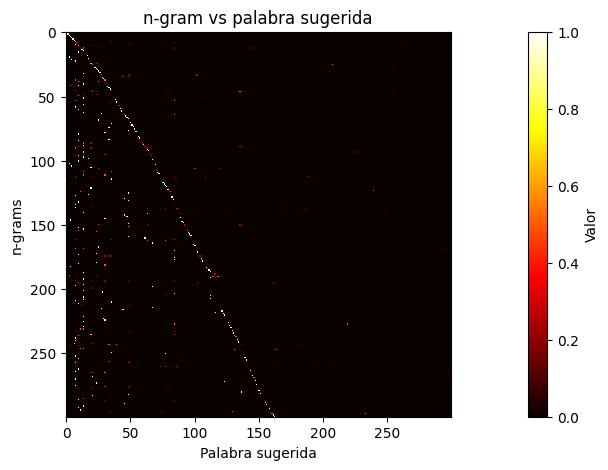

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 5))
plt.imshow(prob_matrix_cess.iloc[:300, :300], cmap='hot', interpolation='nearest')
plt.colorbar(label='Valor')
plt.title("n-gram vs palabra sugerida")
plt.xlabel('Palabra sugerida')
plt.ylabel('n-grams')
plt.show()

In [13]:
prob_matrix_cess.index = pd.MultiIndex.from_tuples(
    prob_matrix_cess.index,
    names=['w_prev', 'w_next']
)
prob_matrix_cess.head()

,,estatal,electricité_de_france,fpa,edf,fpt,anunció,hoy,,jueves,la,...,ivica_racan,llamado,electorado,vote,podremos,finalizar,iniciado,prometidos,a_su_vez,reprochan
w_prev,w_next,,,,,,,,,,,,,,,,,,,,,
el,grupo,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
grupo,estatal,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
estatal,electricité_de_france,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
electricité_de_france,fpa,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
fpa,edf,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
prob_matrix_cess.columns[prob_matrix_cess.iloc[0,:] != 0]

Index(['estatal', 'de', 'mixto', 'malayo', 'concesionario'], dtype='str')

Asi, dada una nueva oración, podríamos sugerir la siguiente palabra. Sería un modelo de generación/recomendación de palabras:

In [17]:
prefix = "el candidato".split()
print(prefix)

['el', 'candidato']


buscamos en el indice las plabras sugeridas:

In [18]:
words = prob_matrix_cess.loc[(prefix[0], prefix[1])]
candidate_words = words[prob_matrix_cess.loc[(prefix[0], prefix[1])] != 0]
print("palabras candidatas: ")
print(candidate_words)

palabras candidatas: 
demócrata    0.666667
electo       0.333333
Name: (el, candidato), dtype: float64


In [19]:
print("Palabra sugerida: ")
candidate_words.index[np.argmax(prob_matrix_cess.columns[9])]

Palabra sugerida: 


'demócrata'

In [21]:
new_sen = "si yo".split()
words = prob_matrix_cess.loc[(new_sen[0], new_sen[1])]
candidate_words = words[prob_matrix_cess.loc[(new_sen[0], new_sen[1])] != 0]
print("palabras candidatas: ")
print(candidate_words)

palabras candidatas: 
Series([], Name: yo, dtype: float64)


#### Conclusiones

- Tenga en cuenta que la generación de $n$-gramas es un paso previo para la construcción de datasets para determinada tarea. En este caso, cada $n$-grama se convierte en un $feature$ para la entrada de un modelo de IA.
- Los $n$-gramas si bien capturan contexto, no generalizan del todo. Esto debido a que se necesitaría un $n$ muy grande para tener un mejor contexto, pero esto haría que se torne muy específico, creando representaciones dispersas.
-  Veremos como se combinan con representaciones vectoriales.